In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import rankdata
import random
from matplotlib.colors import LogNorm

import sys
sys.path.append('..')
from rsa.rsa import triangle_flat

## fmri text

In [ ]:
fmri = pd.read_csv('../../data/results/supplement/fmri_text.csv')
fmri = fmri.pivot(index='embed', columns='norm', values='r2_mean')
fmri = fmri.loc[['fMRI_text_cognival', 'fMRI_text_denoise_128d', 'fMRI_text_denoise_256d', 'fMRI_text_denoise_512d', 'fMRI_text_denoise_1024d']]
fmri

In [ ]:
winner_mask = fmri.apply(lambda col: col == col.max(), axis=0)
winner_mask

In [ ]:
def annotate(df, ax):
    for x, norm_cat in enumerate(df.columns):
        for y, embed in enumerate(df.index):
            annot = df.loc[embed, norm_cat]

            # Scientific notation
            if abs(annot) > 1e3:
                annot = f'{annot:.1e}'
            elif np.isnan(annot):
                annot = ''
            else:
                annot = f'{annot:.2f}'

            # Fontsize and fontweight
            if winner_mask.loc[embed, norm_cat]:
                fontsize, fontweight = 15, 'bold'
            else:
                fontsize, fontweight = 11, 'normal'


            ax.text(
                x + .5, y + .6, annot, fontsize=fontsize, fontweight=fontweight,
                ha='center', va='center', color='black'
            )


fig, ax = plt.subplots(figsize=(8, 5))

vmax = fmri.max().max()
sns.heatmap(
    fmri, vmin=0, cmap='viridis',
    vmax=vmax, annot=False, fmt='', cbar=False, ax=ax
)
ax.set(xlabel='', xticklabels=[], ylabel='')


# Annotates cells
annotate(fmri, ax)

# y ticks
y_tick_labels = fmri.index.str.replace('_', ' ', regex=True)
ax.set_yticks(pd.Series(range(len(y_tick_labels))) + .5)
ax.set_yticklabels(y_tick_labels, fontsize=12)

# x ticks
x_tick_labels = fmri.columns.str.split('_').str[0]
ax.set_xticklabels(x_tick_labels, rotation=90, fontsize=13)

# Sets figure title
ax.set_title('Average Test ${R^2}$', fontsize=15)

## LLMs

In [ ]:
llms = pd.read_csv()

## LLM vs other cosines

In [2]:
mod_1_name = 'GloVe_Wikipedia'
mod_2_name = 'GloVe_CommonCrawl'
rsm_1 = pd.read_pickle(f'../../data/rsms/{mod_1_name}.pkl')
print(f'Read rsm_1, shape: {rsm_1.shape}')
rsm_2 = pd.read_pickle(f'../../data/rsms/{mod_2_name}.pkl')
print(f'Read rsm_2, shape: {rsm_2.shape}')

# Sampling 1000 words from their intersection
intersect = list(set(rsm_1.index) & set(rsm_2.index))
sample = random.sample(intersect, 1000)

rsm_1 = rsm_1.loc[sample, sample]
rsm_2 = rsm_2.loc[sample, sample]

rsm_1.shape, rsm_2.shape

Read rsm_1, shape: (39421, 39421)
Read rsm_2, shape: (44278, 44278)


((1000, 1000), (1000, 1000))

In [3]:
rsm_1, rsm_2 = rsm_1.align(rsm_2, join='inner')
print('Aligned rsms')
rsm_1, rsm_2 = rsm_1.to_numpy(copy=False), rsm_2.to_numpy(copy=False)
print('Converted to numpy')

Aligned rsms
Converted to numpy


In [4]:
rsm_1, rsm_2 = triangle_flat(rsm_1), triangle_flat(rsm_2)
rsm_1_ranked, rsm_2_ranked = rankdata(rsm_1), rankdata(rsm_2)
rsm_1_ranked.shape, rsm_2_ranked.shape

((499500,), (499500,))

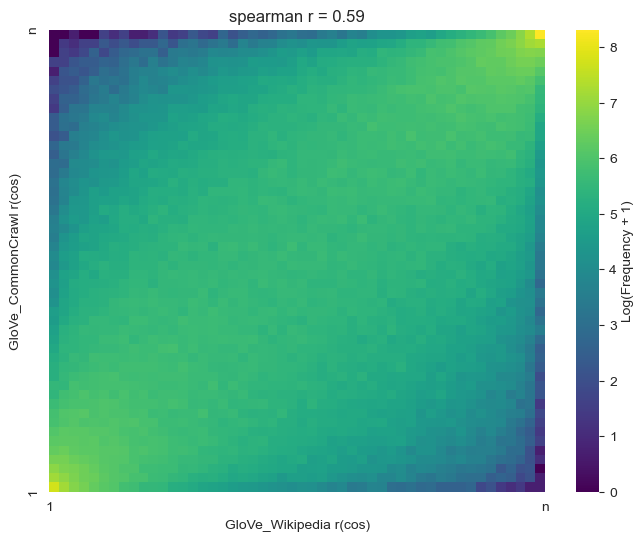

In [39]:
spearman = np.corrcoef(rsm_1_ranked, rsm_2_ranked)[0, 1]

bins = 50

# 1. Compute the 2D frequency matrix and the bin edges
freq_matrix, x_edges, y_edges = np.histogram2d(
    rsm_1_ranked, rsm_2_ranked, bins=bins
)

# 2. Apply a log transformation to the matrix
# Use np.log1p to avoid log(0) errors and handle zeros gracefully
log_freq_matrix = np.log1p(freq_matrix)

# 3. Plot the result using a heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    log_freq_matrix.T, # Transpose the matrix for correct orientation
    cmap='viridis',
    ax=ax,
    cbar_kws={'label': 'Log(Frequency + 1)'} # Add a label to the color bar
)

# Set axis labels and a title
tick_positions = [0, bins]
tick_labels = ['1', 'n']

ax.set(
    xlabel=mod_1_name + ' r(cos)', ylabel=mod_2_name + ' r(cos)',
    title=f"spearman r = {spearman.round(2)}",
    xticks=tick_positions, xticklabels=tick_labels, yticks=tick_positions, yticklabels=tick_labels
)

ax.invert_yaxis()